In [1]:
import warnings

import decoupler as dc
import pertpy as pt
import scanpy as sc

warnings.filterwarnings("ignore")

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation_with_raw.h5ad')

In [6]:
adata = adata[adata.obs.cell_type.str.contains('ligo')]

In [8]:
pdata = dc.pp.pseudobulk(adata, sample_col="sample_id", groups_col="cell_type", layer="counts", mode="sum")
dc.pp.filter_samples(pdata, inplace=True)
pdata

AnnData object with n_obs × n_vars = 120 × 5101
    obs: 'sample_id', 'cell_type', 'run', 'leiden_2', 'cell_class', 'age', 'sex', 'genotype', 'condition', 'psbulk_cells', 'psbulk_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    layers: 'psbulk_props'

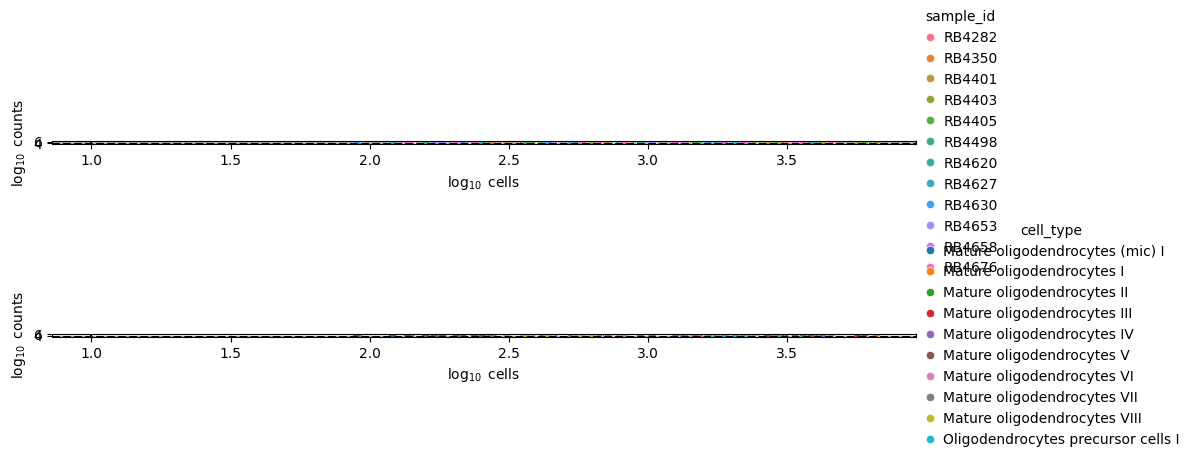

In [9]:
dc.pl.filter_samples(pdata, groupby=["sample_id", "cell_type"], figsize=(12, 4))

In [10]:
pdata.layers["counts"] = pdata.X.copy()

sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.pp.pca(pdata)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [11]:
# Return raw counts to X
dc.pp.swap_layer(pdata, "counts", inplace=True)

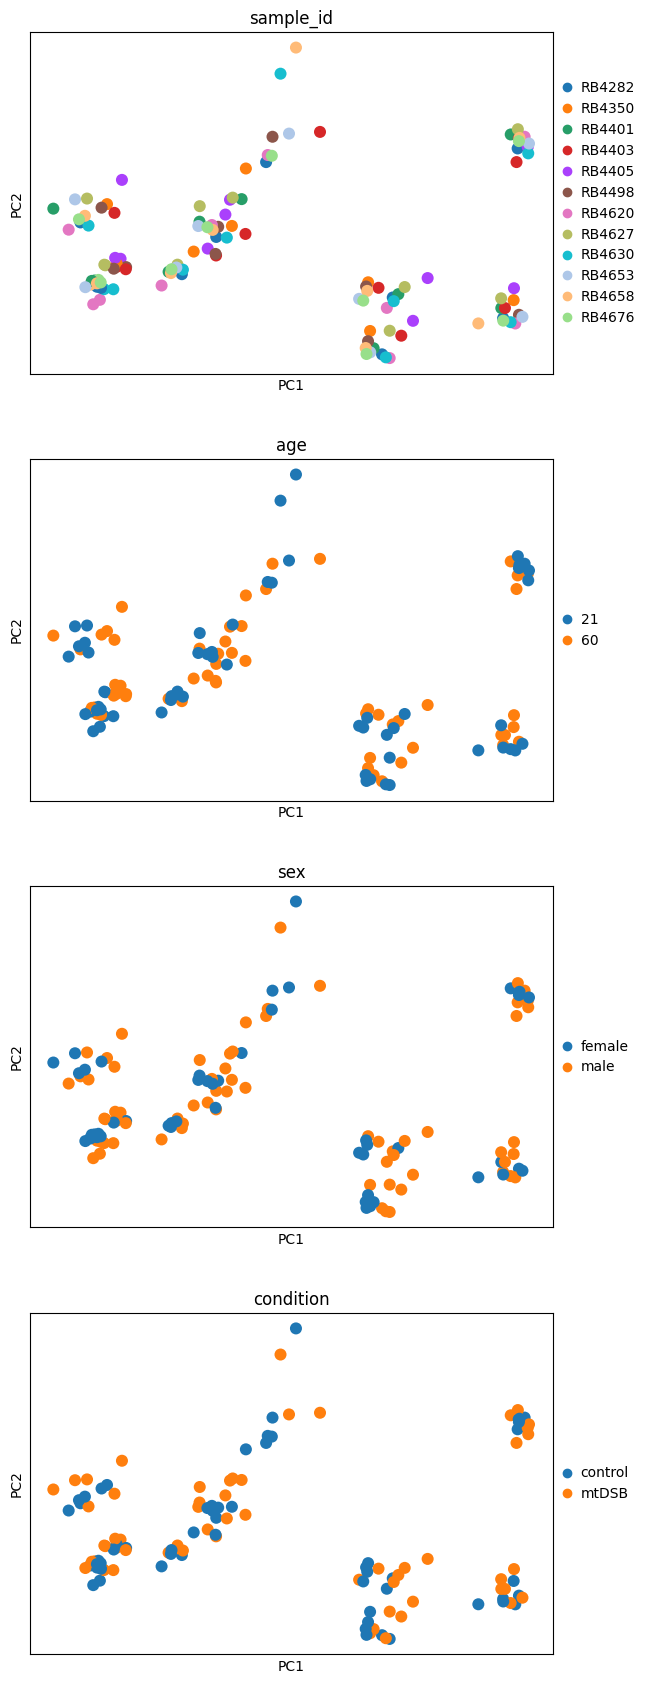

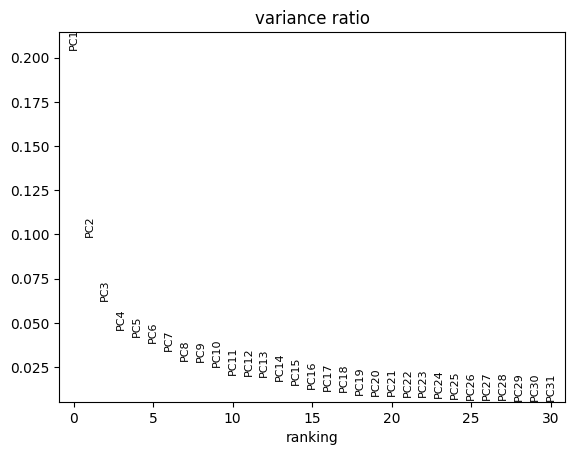

In [12]:
sc.pl.pca(pdata, color=["sample_id", "age", "sex", "condition"], ncols=1, size=300)
sc.pl.pca_variance_ratio(pdata)

In [13]:
pdata_subset = pdata.copy()
pdata_subset.obs = pdata.obs[["sample_id", "age", "sex", "condition"]]

dc.tl.rankby_obsm(
    pdata_subset,
    key="X_pca",
    uns_key="pca_anova",
)

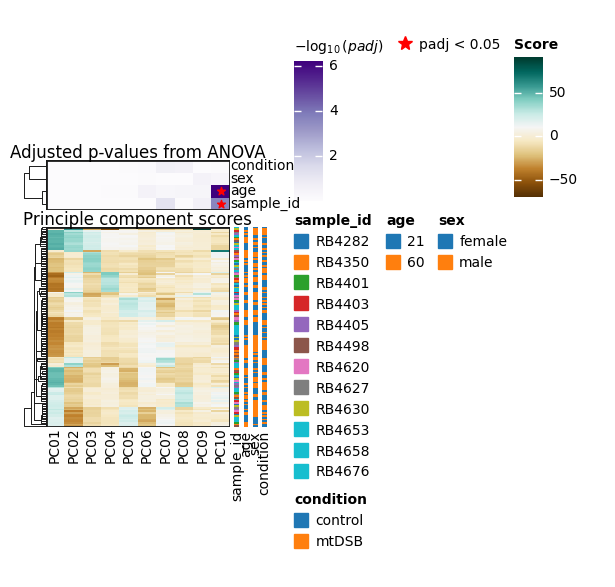

In [14]:
dc.pl.obsm(
    pdata_subset,
    key="pca_anova",
    names=["sample_id", "age", "sex", "condition"],
    titles=["Principle component scores", "Adjusted p-values from ANOVA"],
    cmap_obs={},
)

In [15]:
pdata.obs

,sample_id,cell_type,run,leiden_2,cell_class,age,sex,genotype,condition,psbulk_cells,psbulk_counts
RB4282_Mature oligodendrocytes (mic) I,RB4282,Mature oligodendrocytes (mic) I,output-XETG00045__0060539__RB4282__20250917__1...,43,Mature oligodendrocytes (mic),60,male,PlptTA,control,266.0,161013.0
RB4350_Mature oligodendrocytes (mic) I,RB4350,Mature oligodendrocytes (mic) I,output-XETG00045__0060539__RB4350__20250917__1...,43,Mature oligodendrocytes (mic),60,male,PlptTA,control,254.0,145433.0
RB4401_Mature oligodendrocytes (mic) I,RB4401,Mature oligodendrocytes (mic) I,output-XETG00045__0060539__RB4401__20250917__1...,43,Mature oligodendrocytes (mic),60,female,PlptTA:mtPst1,mtDSB,140.0,74652.0
RB4403_Mature oligodendrocytes (mic) I,RB4403,Mature oligodendrocytes (mic) I,output-XETG00045__0060539__RB4403__20250917__1...,43,Mature oligodendrocytes (mic),60,male,PlptTA:mtPst1,mtDSB,533.0,396014.0
RB4405_Mature oligodendrocytes (mic) I,RB4405,Mature oligodendrocytes (mic) I,output-XETG00045__0060539__RB4405__20250917__1...,43,Mature oligodendrocytes (mic),60,male,PlptTA:mtPst1,mtDSB,90.0,70236.0
...,...,...,...,...,...,...,...,...,...,...,...
RB4627_Oligodendrocytes precursor cells I,RB4627,Oligodendrocytes precursor cells I,output-XETG00045__0060541__RB4627__20250917__1...,20,Oligodendrocytes precursor cells,21,male,PlptTA:mtPst1,mtDSB,1732.0,1415756.0
RB4630_Oligodendrocytes precursor cells I,RB4630,Oligodendrocytes precursor cells I,output-XETG00045__0060541__RB4630__20250917__1...,20,Oligodendrocytes precursor cells,21,male,PlptTA:mtPst1,mtDSB,1648.0,1365598.0
RB4653_Oligodendrocytes precursor cells I,RB4653,Oligodendrocytes precursor cells I,output-XETG00045__0060541__RB4653__20250917__1...,20,Oligodendrocytes precursor cells,21,female,PlptTA:mtPst1,mtDSB,2271.0,1974407.0
RB4658_Oligodendrocytes precursor cells I,RB4658,Oligodendrocytes precursor cells I,output-XETG00045__0060541__RB4658__20250917__1...,20,Oligodendrocytes precursor cells,21,female,PlptTA,control,1881.0,1422174.0


In [16]:
pds2 = pt.tl.PyDESeq2(adata=pdata, design="~condition")


In [17]:
pds2.fit()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 0.18 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.22 seconds.

Fitting LFCs...
... done in 0.22 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 94 outlier genes.

Fitting dispersions...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.02 seconds.

Fitting LFCs...
... done in 0.02 seconds.



In [18]:
res_df = pds2.test_contrasts(pds2.contrast(column="condition", baseline="control", group_to_compare="mtDSB"))


Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Tnfsf9      1.614497        0.505037  0.208224  2.425455  0.015289  0.437405
Adcy1     274.183255       -0.083539  0.181746 -0.459645  0.645771  0.998977
Atp6v0d2    0.778447        1.196954  0.706288  1.694712  0.090130  0.889988
Dnm1l     371.819372        0.051364  0.097448  0.527095  0.598128  0.998977
S100b     165.511418       -0.005378  0.097469 -0.055177  0.955997  0.998977
...              ...             ...       ...       ...       ...       ...
Prf1        0.617866        0.210481  0.788563  0.266917  0.789533  0.998977
Emsy      105.560838       -0.020882  0.035633 -0.586043  0.557846  0.998977
Icam1       6.548681        0.171573  0.398658  0.430377  0.666921  0.998977
Gldc       14.469745       -0.117566  0.230883 -0.509200  0.610612  0.998977
Atp4a       2.374260       -0.066202  0.274310 -0.241340  0.809291  0.998977

[5101 rows x

... done in 0.13 seconds.



In [19]:
res_df.head(10)


,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,Il33,178.446400,-2.127744,0.277643,-7.663610,1.807781e-14,8.326639e-11,None
1,Prl,25.923720,-4.154637,0.591290,-7.026390,2.119457e-12,4.881109e-09,None
2,Fkbp5,103.052701,0.685388,0.103562,6.618116,3.638050e-11,4.560283e-08,None
3,Ccl3,6.713317,2.604332,0.394264,6.605555,3.960298e-11,4.560283e-08,None
4,Maff,7.220378,1.622598,0.251055,6.463126,1.025616e-10,9.447974e-08,None
5,Atf5,167.285233,0.809674,0.148559,5.450184,5.031771e-08,3.862723e-05,None
6,Gh,53.815700,-2.450070,0.482755,-5.075188,3.871140e-07,2.547210e-04,None
7,Zbtb16,322.892501,0.620856,0.124444,4.989048,6.067772e-07,3.493520e-04,None
8,Slc4a1,6.797156,-4.543998,0.931599,-4.877632,1.073668e-06,5.380785e-04,None
9,Trh,12.187975,1.628218,0.334959,4.860954,1.168212e-06,5.380785e-04,None


NaNs encountered, dropping rows with NaNs


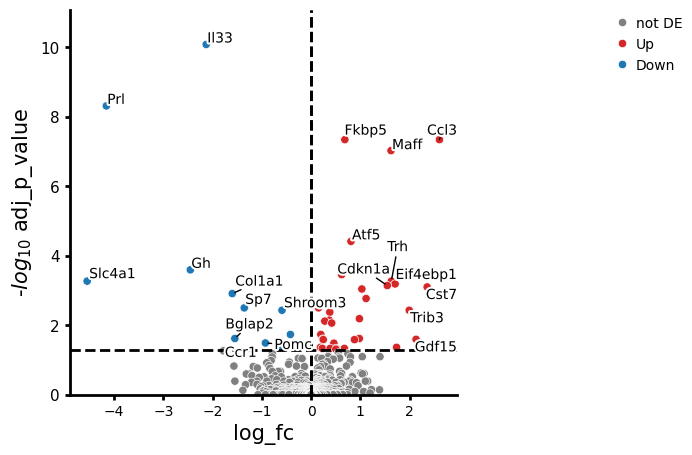

In [27]:
pds2.plot_volcano(res_df, log2fc_thresh=0,to_label = 10 )


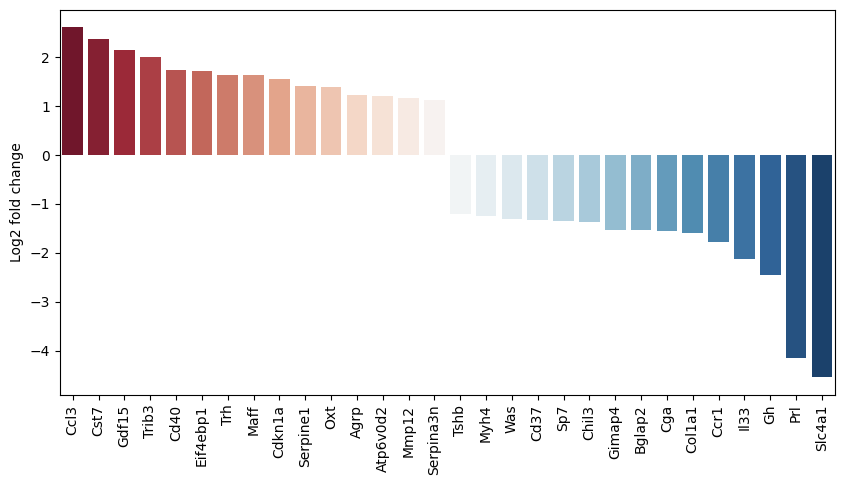

In [21]:
pds2.plot_fold_change(res_df, n_top_vars=15)


In [23]:
res_df = pds2.compare_groups(pdata, column="condition", baseline="control", groups_to_compare=["mtDSB"])


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.17 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.22 seconds.

Fitting LFCs...
... done in 0.21 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 94 outlier genes.

Fitting dispersions...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.02 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Tnfsf9      1.614497        0.505037  0.208224  2.425455  0.015289  0.437405
Adcy1     274.183255       -0.083539  0.181746 -0.459645  0.645771  0.998977
Atp6v0d2    0.778447        1.196954  0.706288  1.694712  0.090130  0.889988
Dnm1l     371.819372        0.051364  0.097448  0.527095  0.598128  0.998977
S100b     165.511418       -0.005378  0.097469 -0.055177  0.955997  0.998977
...              ...             ...       ...       ...       ...       ...
Prf1        0.617866        0.210481  0.788563  0.266917  0.789533  0.998977
Emsy      105.560838       -0.020882  0.035633 -0.586043  0.557846  0.998977
Icam1       6.548681        0.171573  0.398658  0.430377  0.666921  0.998977
Gldc       14.469745       -0.117566  0.230883 -0.509200  0.610612  0.998977
Atp4a       2.374260       -0.066202  0.274310 -0.241340  0.809291  0.998977

[5101 rows x

... done in 0.12 seconds.



In [32]:
res_df = res_df.set_index('variable')

In [33]:
data = res_df[["stat"]].T.rename(index={"stat": "disease.vs.normal"})
data

variable,Il33,Prl,Fkbp5,Ccl3,Maff,Atf5,Gh,Zbtb16,Slc4a1,Trh,...,Ndrg2,Zfand2a,Gucy1a1,Zeb1,Slc2a3,Abcb4,Tmem35a,Tmem63b,Hfm1,Cyct
disease.vs.normal,-7.66361,-7.02639,6.618116,6.605555,6.463126,5.450184,-5.075188,4.989048,-4.877632,4.860954,...,-0.002412,-0.00235,-0.001595,-0.001567,0.001493,0.001373,-0.001067,-0.00076,-0.000481,0.000124


In [35]:
collectri = dc.op.collectri(organism="mouse")
collectri

,source,target,weight,resources,references,sign_decision
0,Myc,Tert,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,Spi1,Bglap3,1.0,ExTRI,10022617,default activation
2,Spi1,Bglap,1.0,ExTRI,10022617,default activation
3,Spi1,Bglap2,1.0,ExTRI,10022617,default activation
4,Smad3,Jun,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
...,...,...,...,...,...,...
43221,Runx1,Lcp2,1.0,DoRothEA-A,20019798,default activation
43222,Runx1,Prr5l,1.0,DoRothEA-A,20019798,default activation
43223,Twist1,Gli1,1.0,DoRothEA-A,11948912,default activation
43224,Usf1,Nup188,1.0,DoRothEA-A,22951020,PMID


In [36]:
# Run
tf_acts, tf_padj = dc.mt.ulm(data=data, net=collectri)

# Filter by sign padj
msk = (tf_padj.T < 0.05).iloc[:, 0]
tf_acts = tf_acts.loc[:, msk]

tf_acts

,Atf5,Bmal2,Dmap1,Elk1,Foxf2,Foxo3,Hivep2,Hmgb2,Id2,Kat6a,...,Nr3c2,Nupr1,Ppargc1a,Prop1,Prrx1,Sall2,Smad9,Sp7,Tbpl2,Trp73
disease.vs.normal,3.259359,3.387815,3.742471,4.864228,-3.475965,3.191225,-3.741927,3.618422,4.529653,4.650158,...,4.549752,4.70236,4.292509,-3.121557,3.175696,3.562735,-3.554001,-3.727709,3.427436,3.699185


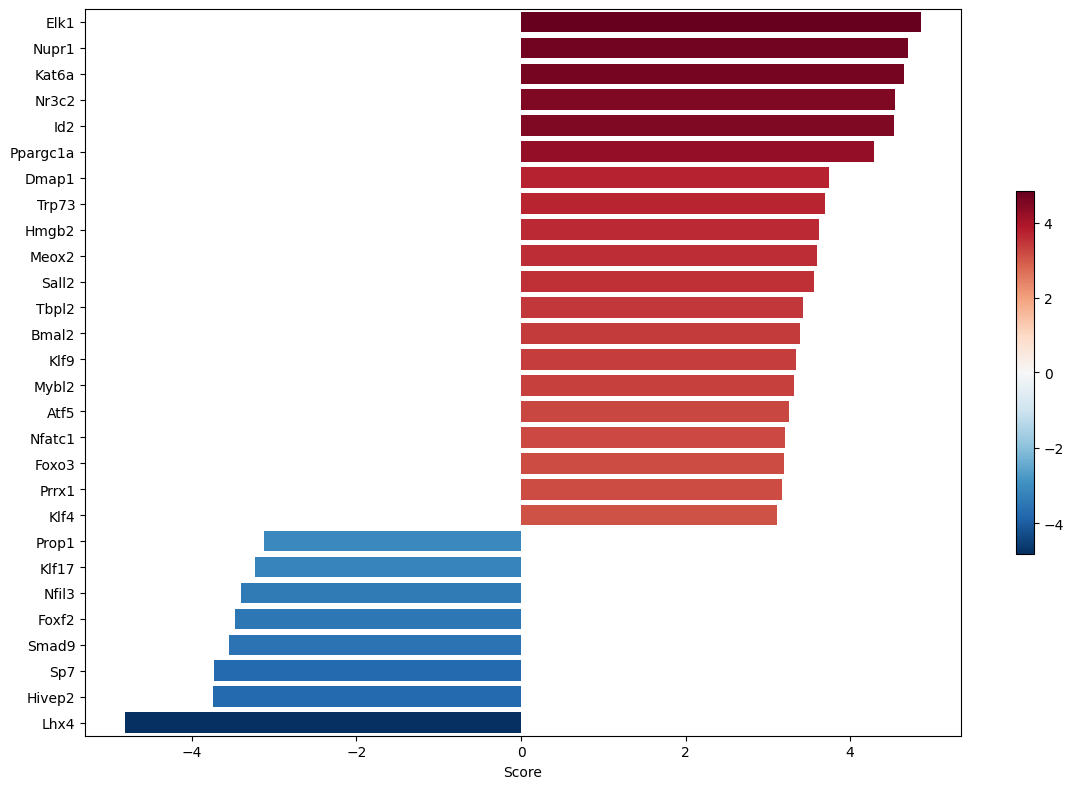

In [38]:
dc.pl.barplot(data=tf_acts, name="disease.vs.normal", figsize=(12, 8), top = 50)

['Elk1',
 'Nupr1',
 'Kat6a',
 'Nr3c2',
 'Id2',
 'Ppargc1a',
 'Dmap1',
 'Trp73',
 'Hmgb2',
 'Meox2']

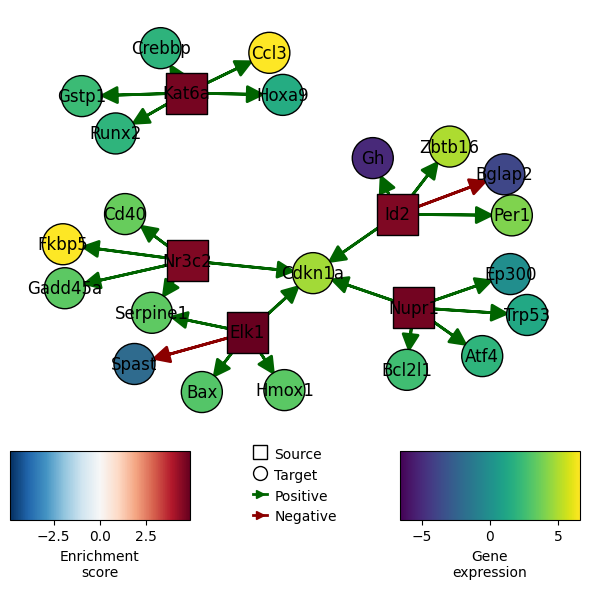

In [53]:
dc.pl.network(
    net=collectri,
    data=data,
    score=tf_acts,
    sources=list(tf_acts.T.sort_values(by = 'disease.vs.normal', ascending = False).head(5).index),
    targets=5,
    figsize=(6, 6),
    vcenter=True,
    by_abs=True,
    size_node=15,
)

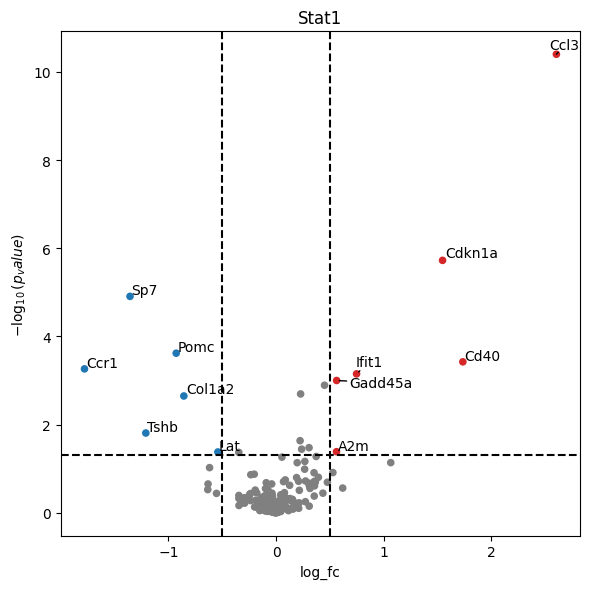

In [60]:
dc.pl.volcano(
    data=res_df,
    x="log_fc",
    y="p_value",
    net=collectri,
    name="Stat1",
    top=20,
    figsize=(6, 6),
)

In [61]:
progeny = dc.op.progeny(organism="mouse")
progeny

,source,target,weight,padj
0,Androgen,Tmprss2,11.490631,2.384806e-47
1,Androgen,Nkx3-1,10.622551,2.205102e-44
2,Androgen,Mboat2,10.472733,4.632376e-44
3,Androgen,Slc38a4,7.363805,1.253071e-39
4,Androgen,Mtmr9,6.130646,2.534403e-38
...,...,...,...,...
60716,p53,Enpp2,2.771405,4.993215e-02
60717,p53,Arrdc4,3.494328,4.996747e-02
60718,p53,Myo1b,-1.148057,4.997905e-02
60719,p53,Ctsc,-1.784693,4.998864e-02


In [62]:
# Run
pw_acts, pw_padj = dc.mt.ulm(data=data, net=progeny)

# Filter by sign padj
msk = (pw_padj.T < 0.05).iloc[:, 0]
pw_acts = pw_acts.loc[:, msk]

pw_acts

,Androgen,EGFR,Hypoxia,JAK-STAT,MAPK,PI3K,VEGF,p53
disease.vs.normal,2.206574,5.457234,2.291653,2.825263,5.554925,2.960707,2.393946,4.384571


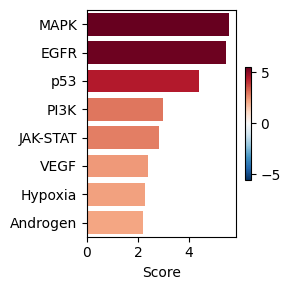

In [63]:
dc.pl.barplot(data=pw_acts, name="disease.vs.normal", figsize=(3, 3))


In [65]:
import numpy as np

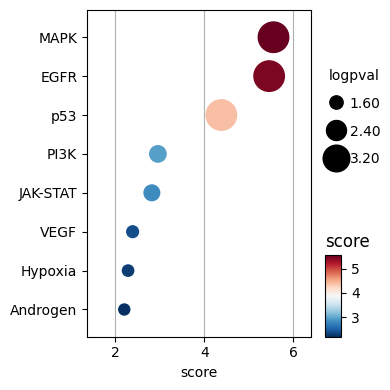

In [66]:
# Transform to df
df = pw_acts.melt(value_name="score").merge(
    pw_padj.melt(value_name="pvalue")
    .assign(logpval=lambda x: x["pvalue"].clip(2.22e-4, 1))
    .assign(logpval=lambda x: -np.log10(x["logpval"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="logpval", c="score", scale=1, figsize=(4, 4))

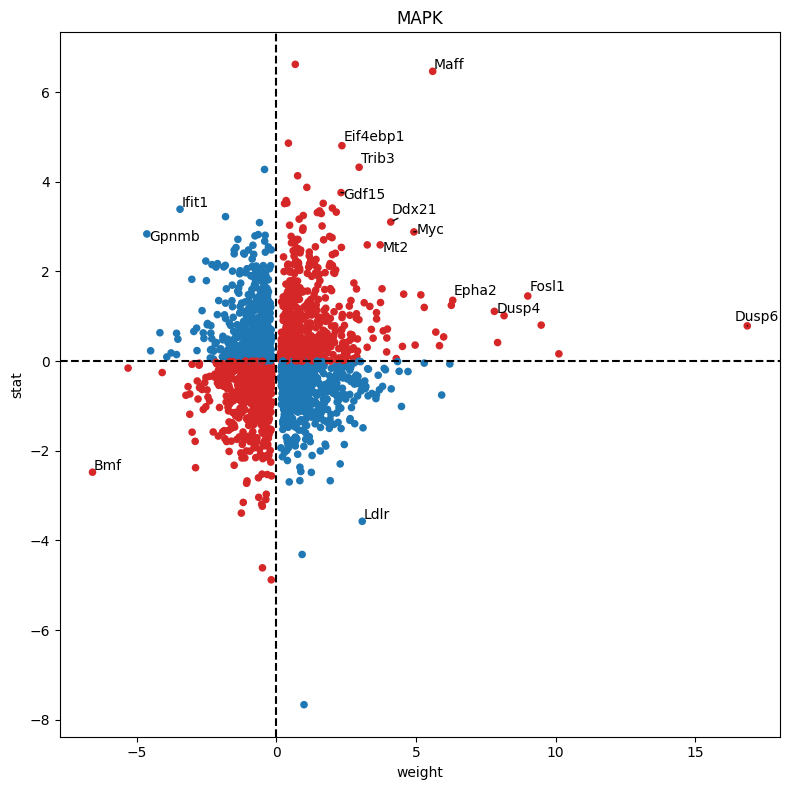

In [67]:
dc.pl.source_targets(data=res_df, x="weight", y="stat", net=progeny, name="MAPK", top=15, figsize=(8, 8))


In [68]:
hallmark = dc.op.hallmark(organism="mouse")
hallmark

,source,target
0,IL2_STAT5_SIGNALING,Maff
1,COAGULATION,Maff
2,HYPOXIA,Maff
3,TNFA_SIGNALING_VIA_NFKB,Maff
4,COMPLEMENT,Maff
...,...,...
7606,PANCREAS_BETA_CELLS,Stxbp1
7607,PANCREAS_BETA_CELLS,Elp4
7608,PANCREAS_BETA_CELLS,Gcg
7609,PANCREAS_BETA_CELLS,Pcsk2


In [69]:
# Run
hm_acts, hm_padj = dc.mt.ulm(data=data, net=hallmark)

# Filter by sign padj
msk = (hm_padj.T < 0.05).iloc[:, 0]
hm_acts = hm_acts.loc[:, msk]

hm_acts

,HYPOXIA,MYC_TARGETS_V1,MYC_TARGETS_V2,P53_PATHWAY,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE
disease.vs.normal,5.699275,5.283648,3.251539,4.438033,3.43599,4.471578


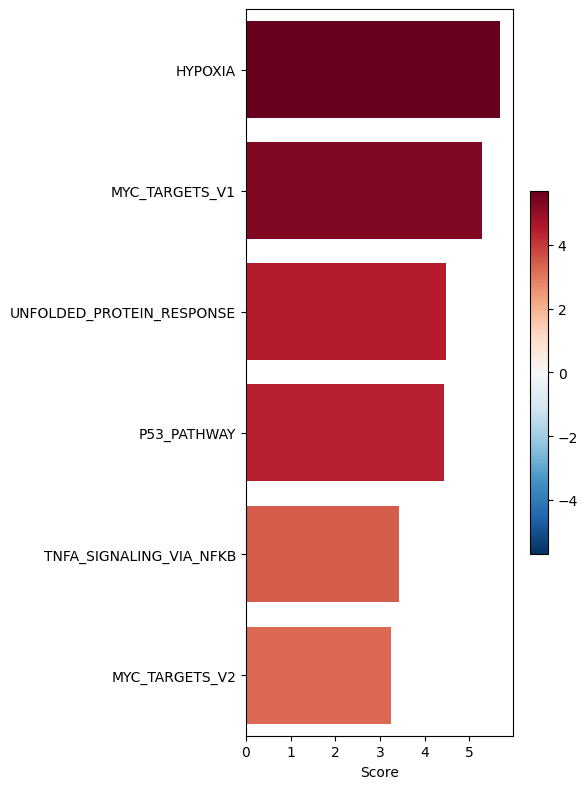

In [70]:
dc.pl.barplot(data=hm_acts, name="disease.vs.normal", figsize=(6, 8))


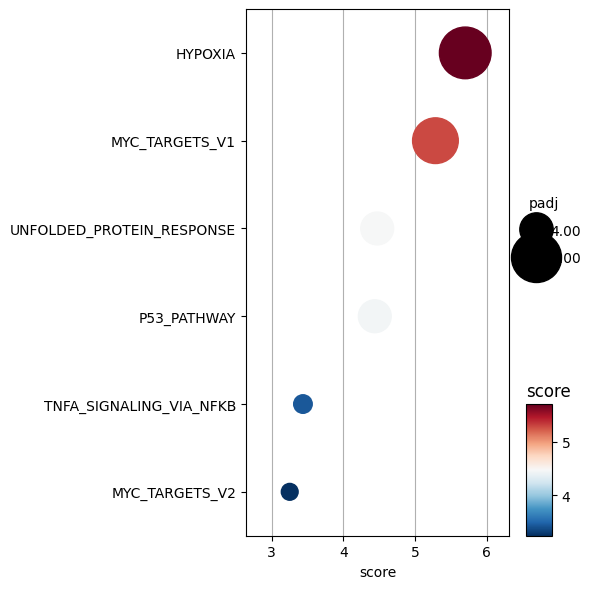

In [73]:
# Tranform to df
df = hm_acts.melt(value_name="score").merge(
    hm_padj.melt(value_name="pvalue")
    .assign(padj=lambda x: x["pvalue"].clip(2.22e-16, 1))
    .assign(padj=lambda x: np.log10(x["pvalue"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="padj", c="score", scale=1, figsize=(6, 6))